In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Ds_Fater (2).csv')

print("--- Five First Rows ---")
display(df.head())

print("\n--- General Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Five First Rows ---


,ID,Age,Sex,Height,Weight,BMI,Hospital,Department,Admission_Date,Last_Visit_Date,...,CAD,Heart_Failure,Arrhythmia,Valvular_Disease,CHD,Diabetes,Smoking,Alcoholism,Depression_Stress,Target
0,2021-06-17_02_02_2381,51,1,160.568394,56.111639,21.763705,Imam,2,2021.06.17,2020-06-22,...,2,True,none,بدون,False,0,0,23,8,0
1,2023-01-23_04_01_8744,49,1,166.315292,73.959014,26.737866,Shariati,1,2023/01/23,2022-04-13,...,1,True,none,متوسط,False,0,0,19,3,0
2,2024-05-28_04_03_14095,51,M,173.007928,90.785885,30.330972,Shariati,3,2024-05-28,NaN,...,2,False,none,متوسط,False,0,0,25,1,0
3,2021-08-04_01_02_2860,46,1,161.374272,50.756266,19.490414,Milad,2,2021-08-04,2018-12-20,...,0,True,none,خفیف,True,0,1,17,1,0
4,2025-05-14_03_05_17946,77,1,177.340476,95.569270,30.388029,Modarres,5,2025-05-14,2023-10-08,...,1,no,none,خفیف,False,Yes,0,39,2,1



--- General Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20040 entries, 0 to 20039
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 20040 non-null  object 
 1   Age                20040 non-null  int64  
 2   Sex                20040 non-null  object 
 3   Height             20040 non-null  float64
 4   Weight             20040 non-null  float64
 5   BMI                20010 non-null  float64
 6   Hospital           20040 non-null  object 
 7   Department         20040 non-null  int64  
 8   Admission_Date     20040 non-null  object 
 9   Last_Visit_Date    17036 non-null  object 
 10  Education_Level    19039 non-null  object 
 11  Troponin_Level     20040 non-null  float64
 12  CPT                20040 non-null  object 
 13  RestingBP          20040 non-null  float64
 14  Cholesterol        20040 non-null  float64
 15  MaxHR              20040 non-null  float64
 16  

In [2]:
df_clean = df.copy()

df_clean['Sex'] = df_clean['Sex'].replace({'1': 1, '0': 0, 'M': 1, 'F': 0, 'man': 1, 'woman': 0})

df_clean['Heart_Failure'] = df_clean['Heart_Failure'].replace({
    'True': 1, 'False': 0, 'no': 0, 'YES': 1, 'yes': 1, '1': 1, '0': 0, 'NO': 0, 'بله': 1, 'خیر': 0
})

df_clean['Diabetes'] = df_clean['Diabetes'].replace({
    '0': 0, 'Yes': 1, '1': 1, 'خیر': 0, 'بله': 1, 'No': 0, 'True': 1, 'False': 0
})

df_clean['Smoking'] = df_clean['Smoking'].replace({
    '0': 0, '1': 1, 'No': 0, 'بله': 1, 'Yes': 1, 'خیر': 0, 'True': 1, 'False': 0
})

df_clean['CAD'] = df_clean['CAD'].replace({
    'No': 0, 'بله': 1, 'Yes': 1, 'خیر': 0, 'True': 1, 'False': 0
})

df_clean['CHD'] = df_clean['CHD'].replace({
    '0': 0, '1': 1, 'No': 0, 'بله': 1, 'Yes': 1, 'خیر': 0, 'True': 1, 'False': 0
})

df_clean['Depression_Stress'] = df_clean['Depression_Stress'].replace({
    'No': 0, 'بله': 1, 'Yes': 1, 'خیر': 0, 'True': 1, 'False': 0
})

df_clean['Valvular_Disease'] = df_clean['Valvular_Disease'].replace({
    'بدون': 0, 'خفیف': 1, 'خفبف': 1, 'متوسط': 2, 'وسط': 2, 'شدید': 3, 'حاد': 3
})

df_clean.loc[df_clean['Alcoholism'] > 50, 'Alcoholism'] = 50

cols_to_fix = ['Sex', 'Heart_Failure', 'Diabetes', 'Smoking', 'CAD', 'CHD', 'Depression_Stress', 'Valvular_Disease', 'Alcoholism']
for col in cols_to_fix:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Cleaning step 2 done!")
print("Check unique values for Valvular Disease:", df_clean['Valvular_Disease'].unique())

Cleaning step 2 done!
Check unique values for Valvular Disease: [0 2 1 3]


In [3]:
df_clean['Education_Level'] = df_clean['Education_Level'].fillna('Unknown')

df_clean['Diabetes'] = df_clean['Diabetes'].fillna(df_clean['Diabetes'].mode()[0])
df_clean['Smoking'] = df_clean['Smoking'].fillna(df_clean['Smoking'].mode()[0])
df_clean['CAD'] = df_clean['CAD'].fillna(df_clean['CAD'].mode()[0])
df_clean['CHD'] = df_clean['CHD'].fillna(df_clean['CHD'].mode()[0])
df_clean['Depression_Stress'] = df_clean['Depression_Stress'].fillna(df_clean['Depression_Stress'].mode()[0])

df_clean['Arrhythmia'] = df_clean['Arrhythmia'].fillna('none')

print("Number of missing values after correction:")
print(df_clean[['Education_Level', 'Diabetes', 'Smoking', 'Arrhythmia', 'CAD', 'CHD', 'Depression_Stress']].isnull().sum())

Number of missing values after correction:
Education_Level      0
Diabetes             0
Smoking              0
Arrhythmia           0
CAD                  0
CHD                  0
Depression_Stress    0
dtype: int64


In [4]:
df_clean['BMI'] = df_clean['BMI'].fillna(df_clean['Weight'] / ((df_clean['Height'] / 100) ** 2))

df_clean.loc[df_clean['MaxHR'] > 200, 'MaxHR'] = 200

if 'ID' in df_clean.columns:
    df_clean.drop(columns=['ID'], inplace=True)

print("Number of missing BMI values:", df_clean['BMI'].isnull().sum())
print("Maximum alcohol consumption:", df_clean['Alcoholism'].max())
print("Maximum heart rate:", df_clean['MaxHR'].max())

Number of missing BMI values: 0
Maximum alcohol consumption: 50
Maximum heart rate: 200.0


In [5]:
df_clean['Admission_Date'] = df_clean['Admission_Date'].astype(str).str.replace('.', '-', regex=False).str.replace('/', '-', regex=False)
df_clean['Last_Visit_Date'] = df_clean['Last_Visit_Date'].astype(str).str.replace('.', '-', regex=False).str.replace('/', '-', regex=False)

df_clean['Admission_Date'] = pd.to_datetime(df_clean['Admission_Date'], errors='coerce')
df_clean['Last_Visit_Date'] = pd.to_datetime(df_clean['Last_Visit_Date'], errors='coerce')

df_clean['FollowUp_Period'] = (df_clean['Last_Visit_Date'] - df_clean['Admission_Date']).dt.days

df_clean['FollowUp_Period'] = df_clean['FollowUp_Period'].fillna(0)
df_clean.loc[df_clean['FollowUp_Period'] < 0, 'FollowUp_Period'] = 0

df_clean.drop(columns=['Admission_Date', 'Last_Visit_Date'], inplace=True)

print("Dates were successfully converted to numbers")
print("Average follow-up days of patients:", df_clean['FollowUp_Period'].mean())

Dates were successfully converted to numbers
Average follow-up days of patients: 0.1093313373253493


In [6]:
df_final = pd.get_dummies(df_clean, columns=['Hospital', 'CPT', 'Education_Level', 'Arrhythmia'], dtype=int)

print("Final columns prepared for the model")
print(df_final.columns)

print("\nTotal number of empty values left", df_final.isnull().sum().sum())

data = df_final.copy()

Final columns prepared for the model
Index(['Age', 'Sex', 'Height', 'Weight', 'BMI', 'Department', 'Troponin_Level',
       'RestingBP', 'Cholesterol', 'MaxHR', 'CAD', 'Heart_Failure',
       'Valvular_Disease', 'CHD', 'Diabetes', 'Smoking', 'Alcoholism',
       'Depression_Stress', 'Target', 'FollowUp_Period', 'Hospital_Imam',
       'Hospital_Milad', 'Hospital_Modarres', 'Hospital_Shariati',
       'CPT_Asymptomatic', 'CPT_Atypical', 'CPT_Non-anginal', 'CPT_Typical',
       'Education_Level_Bachelor+', 'Education_Level_High School',
       'Education_Level_Illiterate', 'Education_Level_Primary',
       'Education_Level_Secondary', 'Education_Level_Unknown', 'Arrhythmia_AF',
       'Arrhythmia_PVC', 'Arrhythmia_SVT', 'Arrhythmia_af', 'Arrhythmia_none',
       'Arrhythmia_pvc', 'Arrhythmia_svt'],
      dtype='object')

Total number of empty values left 0


In [7]:
for arrhythmia in ['AF', 'PVC', 'SVT']:
    lower = f'Arrhythmia_{arrhythmia.lower()}'
    upper = f'Arrhythmia_{arrhythmia}'
    if lower in data.columns and upper in data.columns:
        data[upper] = data[upper] | data[lower]
        data.drop(columns=[lower], inplace=True)
    elif lower in data.columns:
        data.rename(columns={lower: upper}, inplace=True)

print("Final number of columns:", len(data.columns))

Final number of columns: 38


--- Model Performance ---
Train Accuracy: 89.55%
Test Accuracy: 89.47%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.99      0.91      2265
           1       0.99      0.77      0.86      1743

    accuracy                           0.89      4008
   macro avg       0.92      0.88      0.89      4008
weighted avg       0.91      0.89      0.89      4008



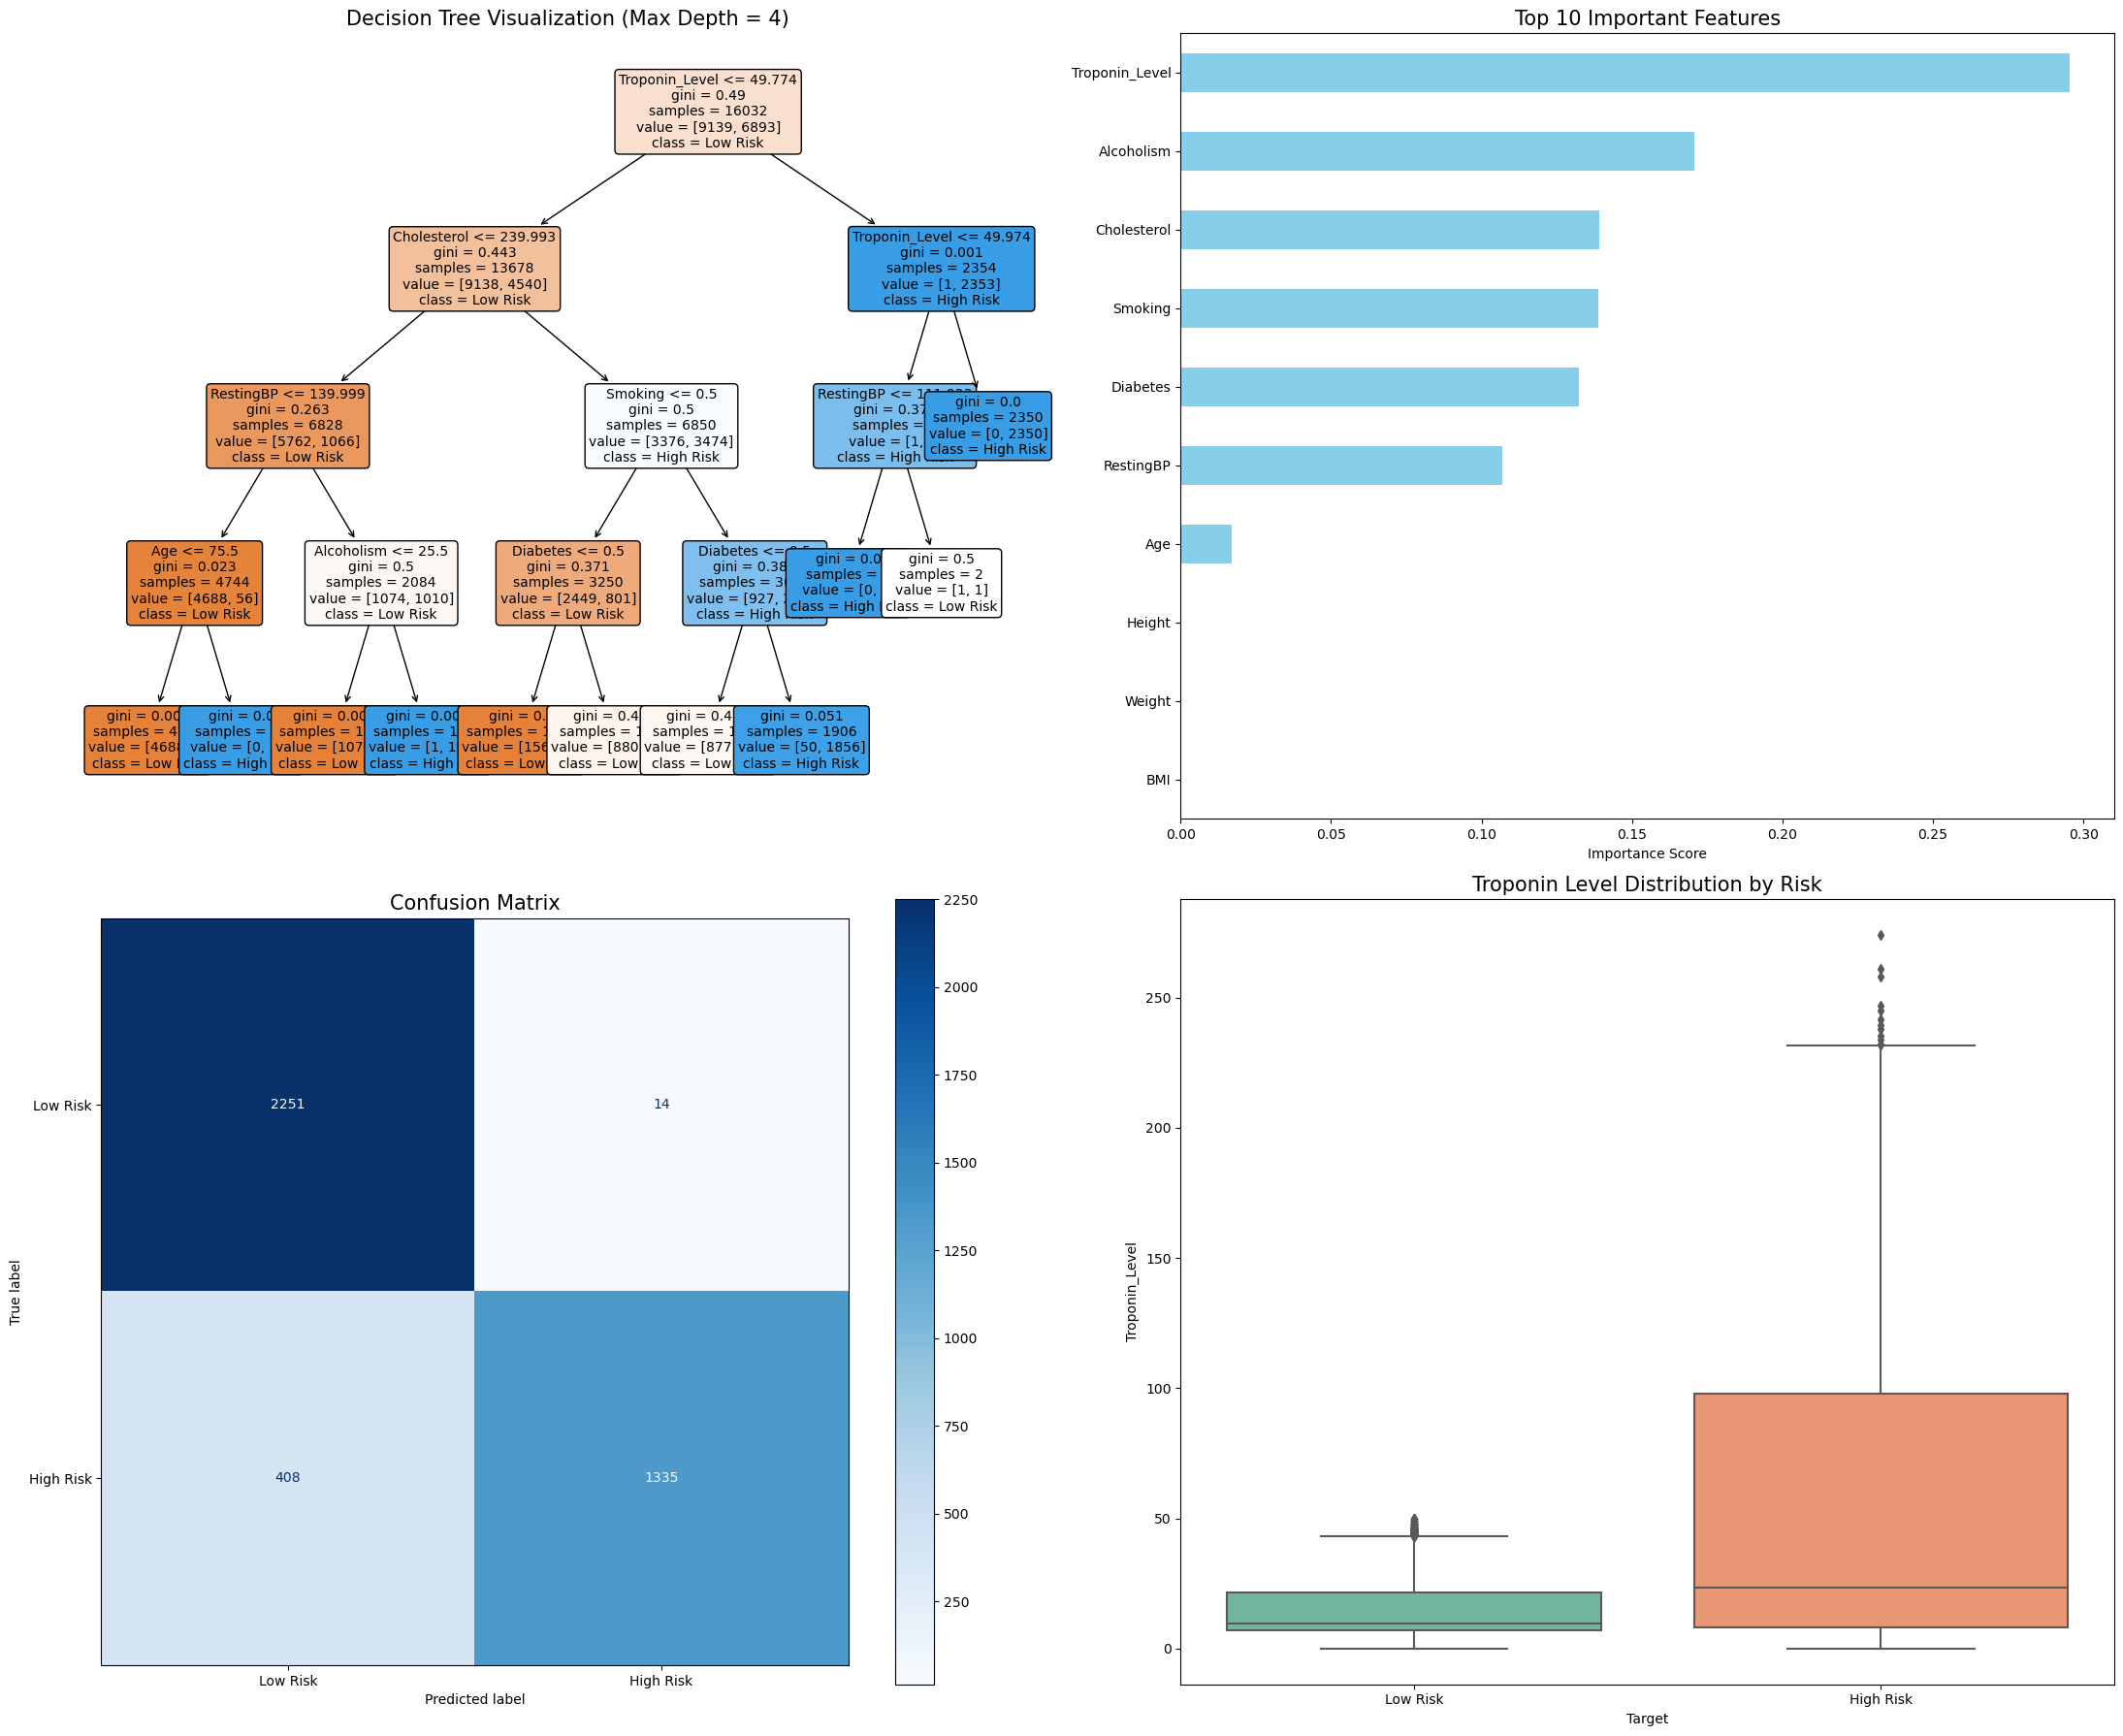

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data_final = data.apply(pd.to_numeric, errors='coerce').fillna(0)


X = data_final.drop(columns=['Target'])
y = data_final['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=2,
    min_samples_split=2,
    min_samples_leaf=2
)
tree.fit(X_train, y_train)


y_pred = tree.predict(X_test)
train_pred = tree.predict(X_train)


print(f"--- Model Performance ---")
print(f"Train Accuracy: {accuracy_score(y_train, train_pred)*100:.2f}%")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


fig, axes = plt.subplots(2, 2, figsize=(22, 18))


plot_tree(tree, feature_names=X.columns.tolist(), class_names=['Low Risk', 'High Risk'], 
          filled=True, rounded=True, fontsize=10, ax=axes[0, 0])
axes[0, 0].set_title("Decision Tree Visualization (Max Depth = 4)", fontsize=15)


imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=True)
imp.tail(10).plot(kind='barh', color='skyblue', ax=axes[0, 1])
axes[0, 1].set_title("Top 10 Important Features", fontsize=15)
axes[0, 1].set_xlabel("Importance Score")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Blues', ax=axes[1, 0], values_format='d')
axes[1, 0].set_title("Confusion Matrix", fontsize=15)


sns.boxplot(x=y, y=X['Troponin_Level'], ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title("Troponin Level Distribution by Risk", fontsize=15)
axes[1, 1].set_xticklabels(['Low Risk', 'High Risk'])

plt.tight_layout()
plt.show()